# TSP moving-average lookback grid search

This notebook searches for a recommended moving-average lookback for each TSP fund. Each candidate uses a lagged trend signal: the target fund is held when it is above its moving average; otherwise the portfolio holds the configured defensive fallback fund. Signals are refreshed at the configured rebalance frequency and never use future prices.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('default')

## Configuration

`MA_RANGE` controls the windows searched. `FALLBACK_FUND` is used when a fund is below its moving average. `OBJECTIVE` determines the recommended lookback reported for each fund.

In [2]:
DATA_URL = 'https://www.tsp.gov/data/fund-price-history.csv'
if Path('portfolio/data').exists():
    DATA_DIR = Path('portfolio/data')
elif Path('../../portfolio/data').exists():
    DATA_DIR = Path('../../portfolio/data')
else:
    DATA_DIR = Path('data')
CACHE_PATH = DATA_DIR / 'fund-price-history.csv'
START_DATE = None  # e.g. '2010-01-01'; None uses all available history
RISK_FREE_RATE = 0.02
TRADING_DAYS = 252
MA_RANGE = range(50, 301, 10)
REBALANCE_FREQUENCY = 'M'  # 'D' for daily, 'M' for monthly
FALLBACK_FUND = 'G Fund'
OBJECTIVE = 'Sharpe'  # CAGR, Sharpe, MaxDD, Sortino, or Calmar

SEARCH_FUNDS = [
    'G Fund',
    'F Fund',
    'C Fund',
    'S Fund',
    'I Fund',
]

## Load and clean TSP prices

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
if not CACHE_PATH.exists():
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/131.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/csv,text/plain;q=0.9,*/*;q=0.8',
        'Referer': 'https://www.tsp.gov/',
    }
    response = requests.get(DATA_URL, headers=headers, timeout=30)
    response.raise_for_status()
    CACHE_PATH.write_bytes(response.content)
    print(f'Downloaded {len(response.content):,} bytes to {CACHE_PATH}')
else:
    print(f'Using cached file: {CACHE_PATH}')

raw = pd.read_csv(CACHE_PATH)
date_candidates = [
    column for column in raw.columns
    if str(column).strip().lower() in {'date', 'as of date', 'price date'}
]
date_column = date_candidates[0] if date_candidates else raw.columns[0]
raw[date_column] = pd.to_datetime(raw[date_column], errors='coerce')
prices = raw.set_index(date_column).sort_index()
prices = prices.apply(
    lambda series: pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False), errors='coerce'
    )
)
prices = prices.loc[:, prices.notna().sum() >= 20].dropna(how='all')
prices = prices[~prices.index.duplicated(keep='last')]

missing = sorted(set(SEARCH_FUNDS + [FALLBACK_FUND]) - set(prices.columns))
if missing:
    raise ValueError(f'Funds missing from TSP data: {missing}')
print(f'Data range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Searching funds: {SEARCH_FUNDS}')

Using cached file: ../../portfolio/data/fund-price-history.csv
Data range: 2003-05-31 to 2026-08-21
Searching funds: ['G Fund', 'F Fund', 'C Fund', 'S Fund', 'I Fund']


## Run the lookback search

The target fund is held when its lagged trend signal is active. Otherwise, the daily return comes from the fallback fund. This makes the comparison consistent with a defensive TSP implementation rather than assigning a zero return while a signal is off.

In [4]:
def performance_metrics(daily_returns, risk_free=RISK_FREE_RATE):
    returns = daily_returns.dropna().astype(float)
    if len(returns) < 2:
        return pd.Series({
            'CAGR': np.nan, 'Sharpe': np.nan, 'MaxDD': np.nan,
            'Sortino': np.nan, 'Calmar': np.nan, 'Years': np.nan,
        })
    equity = (1.0 + returns).cumprod()
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = equity.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    max_dd = drawdown.min()
    daily_rf = (1.0 + risk_free) ** (1.0 / TRADING_DAYS) - 1.0
    excess = returns - daily_rf
    volatility = returns.std(ddof=1)
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / volatility if volatility > 0 else np.nan
    downside = np.minimum(excess, 0.0)
    downside_deviation = np.sqrt(np.mean(downside ** 2))
    sortino = (
        np.sqrt(TRADING_DAYS) * excess.mean() / downside_deviation
        if downside_deviation > 0 else np.nan
    )
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({
        'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': max_dd,
        'Sortino': sortino, 'Calmar': calmar, 'Years': years,
    })

def backtest_lookback(fund, lookback):
    target = prices[fund].dropna()
    fallback = prices[FALLBACK_FUND].reindex(target.index).ffill()
    fund_returns = target.pct_change()
    fallback_returns = fallback.pct_change()

    # The moving average and signal are both lagged before returns are applied.
    moving_average = target.rolling(int(lookback)).mean()
    raw_signal = target.gt(moving_average).shift(1).fillna(False)

    if REBALANCE_FREQUENCY == 'D':
        signal = raw_signal
    else:
        periods = pd.Series(
            target.index.to_period(REBALANCE_FREQUENCY), index=target.index
        )
        rebalance = periods.ne(periods.shift(1)).fillna(True)
        signal = raw_signal.where(rebalance).ffill().fillna(False)

    signal = signal.astype(bool)
    strategy_returns = fund_returns.where(signal, fallback_returns)
    if START_DATE is not None:
        strategy_returns = strategy_returns.loc[pd.Timestamp(START_DATE):]
    return strategy_returns.dropna(), signal.reindex(strategy_returns.index)

rows = []
signals_by_fund = {}
for fund in SEARCH_FUNDS:
    for lookback in MA_RANGE:
        strategy_returns, signal = backtest_lookback(fund, lookback)
        metrics = performance_metrics(strategy_returns)
        rows.append({
            'Fund': fund, 'MA_Length': int(lookback), **metrics.to_dict()
        })
        if lookback == min(MA_RANGE):
            signals_by_fund[fund] = signal

results = pd.DataFrame(rows)
if OBJECTIVE not in results.columns:
    raise ValueError(f'OBJECTIVE must be one of: {list(results.columns[2:])}')

recommended_rows = []
for fund, group in results.groupby('Fund', sort=False):
    valid = group.dropna(subset=[OBJECTIVE])
    if valid.empty:
        continue
    best = valid.sort_values(
        [OBJECTIVE, 'Sharpe', 'CAGR'], ascending=[False, False, False]
    ).iloc[0]
    recommended_rows.append(best)

recommendations = pd.DataFrame(recommended_rows).set_index('Fund')
recommended_lookbacks = recommendations['MA_Length'].astype(int).to_dict()

print(f'Objective: {OBJECTIVE}')
print(f'Rebalance frequency: {REBALANCE_FREQUENCY}')
display(recommendations[['MA_Length', 'CAGR', 'Sharpe', 'MaxDD', 'Sortino', 'Calmar', 'Years']].style.format({
    'MA_Length': '{:.0f}', 'CAGR': '{:.2%}', 'Sharpe': '{:.2f}',
    'MaxDD': '{:.2%}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}', 'Years': '{:.1f}',
}))

print('\nCopy-ready LOOKBACKS configuration:')
print('LOOKBACKS = {')
for fund, lookback in recommended_lookbacks.items():
    print(f"    {fund!r}: {lookback},")
print('}')

Objective: Sharpe
Rebalance frequency: M


,MA_Length,CAGR,Sharpe,MaxDD,Sortino,Calmar,Years
Fund,,,,,,,
G Fund,50,3.06%,3.64,0.00%,17.66,nan,23.2
F Fund,80,4.11%,0.64,-6.37%,0.91,0.65,23.2
C Fund,130,10.35%,0.74,-21.15%,1.02,0.49,23.2
S Fund,100,10.70%,0.67,-19.76%,0.95,0.54,23.2
I Fund,80,9.14%,0.65,-16.26%,0.91,0.56,23.2



Copy-ready LOOKBACKS configuration:
LOOKBACKS = {
    'G Fund': 50,
    'F Fund': 80,
    'C Fund': 130,
    'S Fund': 100,
    'I Fund': 80,
}


## Search results and robustness

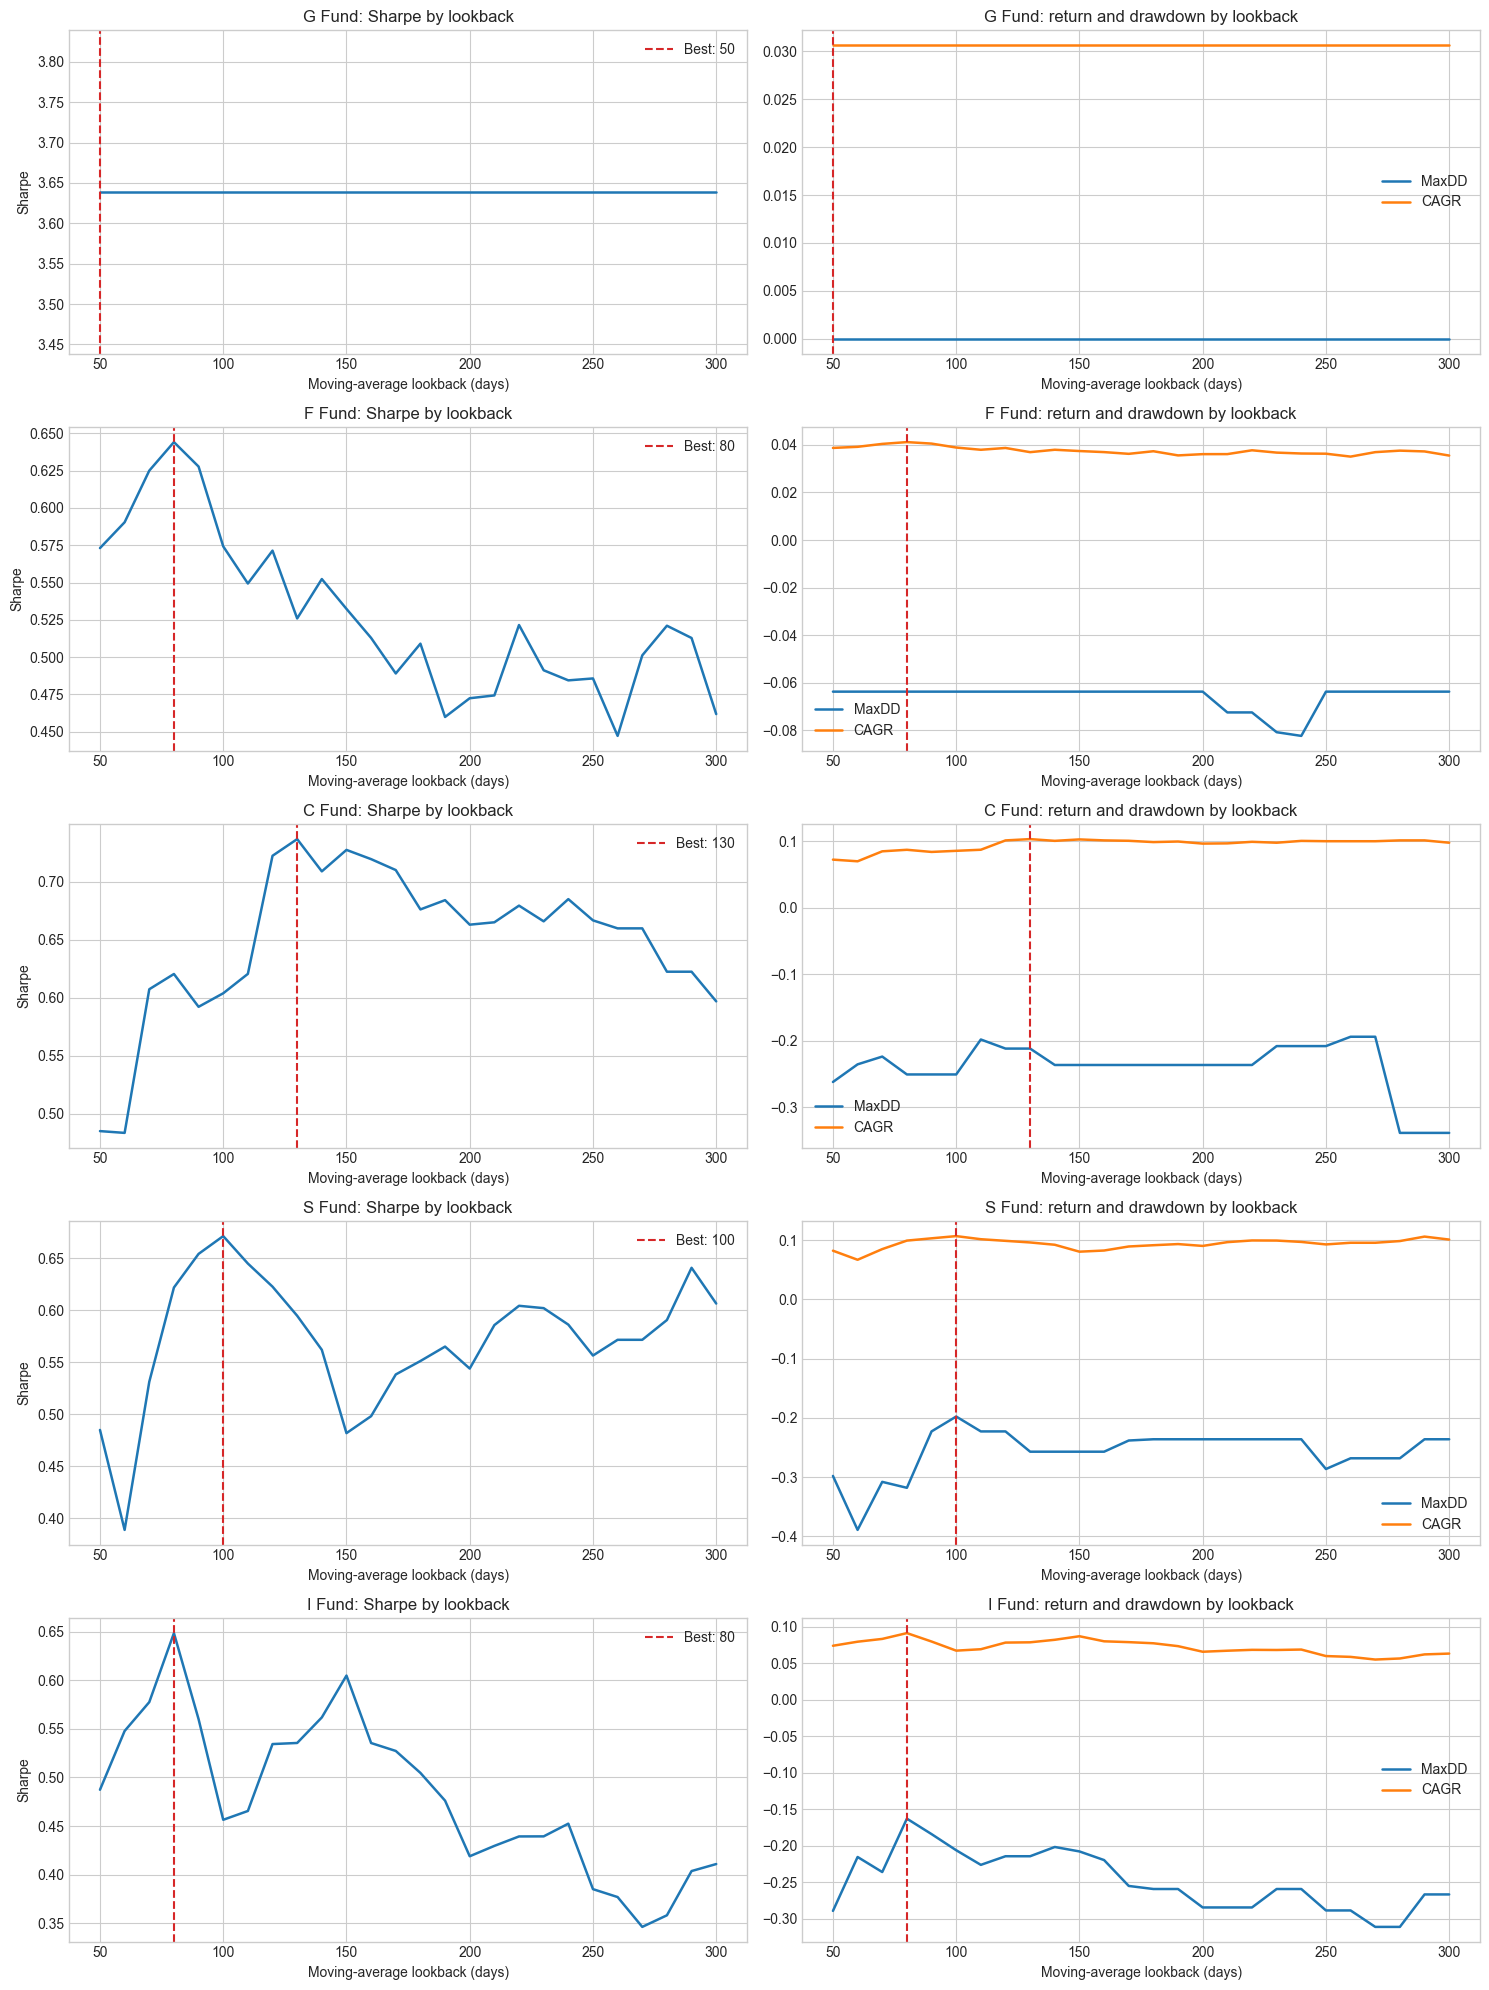

,Fund,MA_Length,CAGR,Sharpe,MaxDD,Sortino,Calmar
60,C Fund,130,10.35%,0.74,-21.15%,1.02,0.49
62,C Fund,150,10.30%,0.73,-23.62%,1.01,0.44
59,C Fund,120,10.15%,0.72,-21.15%,1.00,0.48
63,C Fund,160,10.15%,0.72,-23.62%,1.00,0.43
64,C Fund,170,10.09%,0.71,-23.62%,0.98,0.43
29,F Fund,80,4.11%,0.64,-6.37%,0.91,0.65
30,F Fund,90,4.05%,0.63,-6.37%,0.89,0.64
28,F Fund,70,4.04%,0.62,-6.37%,0.88,0.63
27,F Fund,60,3.92%,0.59,-6.37%,0.83,0.61
31,F Fund,100,3.89%,0.57,-6.37%,0.81,0.61


In [5]:
fig, axes = plt.subplots(len(SEARCH_FUNDS), 2, figsize=(15, 4 * len(SEARCH_FUNDS)), squeeze=False)
for row_number, fund in enumerate(SEARCH_FUNDS):
    fund_results = results[results['Fund'].eq(fund)].set_index('MA_Length')
    best_length = int(recommendations.loc[fund, 'MA_Length'])
    axes[row_number, 0].plot(fund_results.index, fund_results['Sharpe'], linewidth=1.8)
    axes[row_number, 0].axvline(best_length, color='tab:red', linestyle='--', label=f'Best: {best_length}')
    axes[row_number, 0].set_title(f'{fund}: Sharpe by lookback')
    axes[row_number, 0].set_xlabel('Moving-average lookback (days)')
    axes[row_number, 0].set_ylabel('Sharpe')
    axes[row_number, 0].legend()

    axes[row_number, 1].plot(fund_results.index, fund_results['MaxDD'], linewidth=1.8, label='MaxDD')
    axes[row_number, 1].plot(fund_results.index, fund_results['CAGR'], linewidth=1.8, label='CAGR')
    axes[row_number, 1].axvline(best_length, color='tab:red', linestyle='--')
    axes[row_number, 1].set_title(f'{fund}: return and drawdown by lookback')
    axes[row_number, 1].set_xlabel('Moving-average lookback (days)')
    axes[row_number, 1].legend()

plt.tight_layout()
plt.show()

top_windows = (
    results.sort_values(['Fund', OBJECTIVE], ascending=[True, False])
    .groupby('Fund', sort=False).head(5)
    [['Fund', 'MA_Length', 'CAGR', 'Sharpe', 'MaxDD', 'Sortino', 'Calmar']]
)
display(top_windows.style.format({
    'MA_Length': '{:.0f}', 'CAGR': '{:.2%}', 'Sharpe': '{:.2f}',
    'MaxDD': '{:.2%}', 'Sortino': '{:.2f}', 'Calmar': '{:.2f}',
}))